<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Validation NuSQuIDS 5: Solar Neutrino Earth Detection 
---

This notebook computes:

1. **Energy-differential oscillated flux** — From `solar_probability_state`/`solar_probability_mass`combined with the tabulated per-source spectral shapes in `data/solar/spectra/`
2. **Annual Earth-regeneration averaging** — From `earth_probability_exposure` and `build_nadir_exposure` 
3. **A nuSQuIDS cross-check of the Sun→Earth incoherent regeneration** — nuSQuIDS has no single call that chains a solar mass-basis
   state into an Earth body, so this notebook builds it explicitly by propagating each mass eigenstate through nuSQuIDS's `Earth`/`EarthAtm`
   body separately and recombining incoherently, then compares the result with `earth_probability_state_analytical`.
4. **Detection physics** — The exact tree-level $\nu$–$e^-$ elastic scattering cross section, and a literature-anchored radiochemical-capture
   comparison (Homestake, GALLEX/SAGE), combined with real target masses to produce **counts/year**, with and without oscillations.

## Table of Contents

| § | Title |
|---|-------|
| [0](#0.-Theory-Background) | **Theory Background** — differential flux, ES cross section, SNU, detector table |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Configuration** — sources, spectra, detectors |
| [3](#3.-Energy-Differential-Oscillated-Flux) | **Energy-Differential Oscillated Flux** — real B16 spectral shapes |
| [4](#4.-Annual-Earth-Regenerated-Flux-at-Real-Sites) | **Annual Earth-Regenerated Flux** — `earth_probability_exposure` at real latitudes |
| [5](#5.-nuSQuIDS-Cross-Check:-Sun-to-Earth-Regeneration) | **nuSQuIDS Cross-Check** — mass-eigenstate Earth propagation |
| [6](#6.-Detection-Cross-Sections) | **Detection Cross Sections** — $\nu$–$e^-$ ES formula |
| [7](#7.-Annual-Event-Rate-Predictions) | **Annual Event-Rate Predictions** — SNO, Super-K, Borexino, Homestake, GALLEX/SAGE |
| [8](#8.-Export-Tables) | **Export Tables** |
| [9](#9.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 From oscillation probability to a detectable count rate

The quantity `solar_probability_state` returns is a probability, and `solar_profile.flux(source)`
is a single energy-integrated number (cm$^{-2}$ s$^{-1}$).

$$
\frac{{\rm d}\Phi_s}{{\rm d}E}(E) = \Phi_s \cdot f_s(E), \qquad
\int f_s(E)\,{\rm d}E = 1,
$$

the normalized per-source spectral shape $f_s(E)$ (bundled in
`data/solar/spectra/spectrum_<source>.csv`, loaded here with the existing
but previously unused `medium.solar.io.load_spectrum_csv`), and a detection
cross section $\sigma_\alpha(E)$ turning a flavour-$\alpha$ flux into a rate
per target particle:

$$
R = N_{\rm target}\int_{E_{\rm thr}}^{E_{\rm max}}
\sum_\alpha \sigma_\alpha(E)\,P(\nu_e\to\nu_\alpha; E)\,
\frac{{\rm d}\Phi_s}{{\rm d}E}(E)\,{\rm d}E .
$$

This notebook builds $\sigma_\alpha(E)$ and $N_{\rm target}$ explicitly in
§6–§7; everything upstream of that (the flux and the probability) reuses
`tpeanuts` machinery already validated elsewhere.

### 0.2 Earth regeneration of an incoherent solar mixture

A detector does not see $P(\nu_e\to\nu_\alpha)$ at the solar surface — it
sees that state *after* crossing (part of) the Earth, at a nadir angle $\eta$
that changes continuously over a day and a year. `medium.earth` already
implements the full machinery for this:
`solar_probability_mass(...)` gives the incoherent mass-basis weights
$w_i(E)$; `earth_probability_state_analytical(w_i, ..., \eta, ...)` propagates them through
Earth's matter for one $\eta$; `build_nadir_exposure`/`earth_probability_exposure`
average that over a full year of real Earth-Sun-detector geometry for a
given detector latitude. 

### 0.3 Neutrino–electron elastic scattering (ES)

The tree-level (CC+NC for $\nu_e$, NC-only for $\nu_\mu,\nu_\tau$)
differential cross section for $\nu_\alpha + e^- \to \nu_\alpha + e^-$ is,
in the standard notation of Bahcall (1989) and Giunti & Kim (2007, ch. 15),

$$
\frac{{\rm d}\sigma}{{\rm d}T} = \frac{2 G_F^2 m_e}{\pi}
\left[ g_1^2 + g_2^2\left(1-\frac{T}{E_\nu}\right)^2
- g_1 g_2 \frac{m_e T}{E_\nu^2} \right],
$$

with recoil electron kinetic energy $T\in[0,T_{\max}]$,
$T_{\max}=2E_\nu^2/(m_e+2E_\nu)$, and

$$
g_1 = \begin{cases}\tfrac12+\sin^2\theta_W & (\nu_e)\\[2pt]
-\tfrac12+\sin^2\theta_W & (\nu_\mu,\nu_\tau)\end{cases}, \qquad
g_2 = \sin^2\theta_W \ \ \text{(both)}.
$$

Integrating over $T$ in the ultra-relativistic limit $E_\nu\gg m_e$ gives the
total cross section used here:

$$
\sigma(E_\nu) \approx \frac{2 G_F^2 m_e E_\nu}{\pi}
\left[g_1^2 + \frac{g_2^2}{3} - g_1 g_2\,\frac{m_e}{2E_\nu}\right].
$$

This is exact tree-level electroweak physics (no nuclear-structure input),
reusing `tpeanuts`'s own `G_F_MEV_M2` and `HBARC_MeV_m` constants for the
unit conversion — the same combination pattern as `core/common/potential.py`'s
`_MATTER_FACTOR`. 

**Caveat:** the ultra-relativistic approximation is very
good for $^7$Be/$^8$B/hep ($E\gg m_e=0.511$ MeV) but only approximate for the
lowest-energy $pp$ neutrinos ($E\sim0.1$–0.4 MeV, comparable to $m_e$); it is
kept here as $E_\nu\gg m_e$ is still a reasonable working approximation for a
first-principles pedagogical estimate, not a precision measurement
reproduction.

### 0.4 Radiochemical capture and the SNU unit

Homestake ($^{37}$Cl$\to^{37}$Ar$+e^-$, threshold 0.814 MeV) and
GALLEX/SAGE ($^{71}$Ga$\to^{71}$Ge$+e^-$, threshold 0.233 MeV) are
charged-current-only ($\nu_e$ only) radiochemical experiments. Their nuclear
capture cross sections depend on measured/calculated transition strengths to
excited states of the daughter nucleus and are **not** derivable from
tree-level electroweak theory the way ES is. 

This notebook uses the standard convention: quote rates in **SNU** (Solar Neutrino Units,
$1\ {\rm SNU} = 10^{-36}$ captures/target-atom/s), anchor the *unoscillated*
prediction to a single literature reference value per experiment, and apply
the **survival-probability suppression computed here** (threshold-weighted,
using the real per-source spectra and `solar_probability_state`/`earth_probability_exposure`) on top of
it:

$$
{\rm SNU}_{\rm predicted} = {\rm SNU}_{\rm no\text{-}osc}\times
\frac{\int_{E_{\rm thr}}^{E_{\rm max}} P_{ee}(E)\,\frac{{\rm d}\Phi}{{\rm d}E}(E)\,{\rm d}E}
{\int_{E_{\rm thr}}^{E_{\rm max}} \frac{{\rm d}\Phi}{{\rm d}E}(E)\,{\rm d}E}.
$$

The ratio is rigorously computed physics;
${\rm SNU}_{\rm no\text{-}osc}$ and the measured values quoted in §7 are
**illustrative literature reference numbers** (order-of-magnitude, standard
solar model predictions and the classic experimental results),
explicitly flagged as such — consult Cleveland et al. (1998), Hampel et al.
(1999, GALLEX), Abdurashitov et al. (2009, SAGE), and Bahcall's standard
solar model reviews for precision-grade values.

### 0.5 Detectors covered

| Detector | Channel | Target | Mass | Threshold | Latitude |
|---|---|---|---|---|---|
| SNO | ES ($\nu$–$e^-$) | H$_2$O(D$_2$O) electrons | 1000 t D$_2$O | $\sim$3.5 MeV | 46.47°N |
| Super-Kamiokande | ES ($\nu$–$e^-$) | H$_2$O electrons | 22.5 kt (fiducial) | $\sim$4.5 MeV | 36.43°N |
| Borexino | ES ($\nu$–$e^-$) | scintillator electrons | 100 t (fiducial) | $\sim$0.25 MeV | 42.45°N |
| Homestake | CC ($^{37}$Cl) | perchloroethylene | 615 t | 0.814 MeV | 44.35°N |
| GALLEX/SAGE | CC ($^{71}$Ga) | gallium | 30 t | 0.233 MeV | 42.45°N |

### References

- Bahcall, J. N. (1989). *Neutrino Astrophysics*. Cambridge University Press. (ES cross section, SNU formalism)
- Giunti, C. & Kim, C. W. (2007). *Fundamentals of Neutrino Physics and Astrophysics*. Oxford University Press, ch. 15 (ES cross section).
- Marciano, W. J. & Parsa, Z. (2003). *Neutrino-electron scattering theory*. J. Phys. G 29, 2629.
- Cleveland, B. T. et al. (1998). *Measurement of the solar neutrino flux with the Homestake chlorine detector*. Astrophys. J. 496, 505.
- Hampel, W. et al. (GALLEX) (1999). *GALLEX solar neutrino observations*. Phys. Lett. B 447, 127.
- Abdurashitov, J. N. et al. (SAGE) (2009). *Measurement of the solar neutrino capture rate with gallium metal*. Phys. Rev. C 80, 015807.
- Aharmim, B. et al. (SNO Collaboration) (2013). *Combined analysis of all three phases of solar neutrino data from the Sudbury Neutrino Observatory*. Phys. Rev. C 88, 025501.
- Abe, K. et al. (Super-Kamiokande Collaboration) (2016). *Solar neutrino measurements in Super-Kamiokande-IV*. Phys. Rev. D 94, 052010.
- Agostini, M. et al. (Borexino Collaboration) (2018). $^8$B solar neutrino measurement (as cited in `Earth3_NeutrinoSolar_EarthDetection.ipynb` §8; consult the Borexino Collaboration's published record for the exact journal reference).
- Vinyoles, N. et al. (2017). *A new generation of standard solar models*. Astrophys. J. 835, 202.
- Argüelles, C. A., Salvado, J. & Weaver, C. N. (2022). *nuSQuIDS: A toolbox for neutrino propagation*. Comput. Phys. Commun. 277, 108346.

## 1. Libraries

In [1]:
from __future__ import annotations

%matplotlib inline
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (
    FLAVOUR_LABELS, FLAVOUR_COLORS, to_numpy, save_and_show,
    compare_probability_grids, nusquids_precision_summary,
)
from tpeanuts.external.nusquids.core import (
    NuSQuIDSConfig, is_available as nusquids_is_available,
    probability_earth_massbasis,
)
from tpeanuts.util.context import RuntimeContext
import tpeanuts.util.constant as constant
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.solar.profile import SolarProfile
from tpeanuts.medium.solar.probability import solar_probability_state, solar_probability_mass
from tpeanuts.medium.solar.io import load_spectrum_csv, default_solar_data_dir
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import earth_probability_state_analytical
from tpeanuts.medium.earth.exposure_integration import earth_probability_exposure
from tpeanuts.medium.earth.exposure_table import ExposureParameters, build_nadir_exposure

print(f"torch {torch.__version__}")
from tpeanuts.util.math import numpy_trapezoid


torch 2.12.0+cu126


## 2. Paths and Configuration

### 2.1 Paths and oscillation parameters

In [2]:
config     = load_notebook_config()
ctx        = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("validation", "nusquids")
SHOW       = config.show_plots

oscillation   = PropagationConfig.oscillation_parameters_from_preset("_SM_NUFIT52_NO", antinu=False, context=ctx)
solar_profile = SolarProfile.default(context=ctx)

NSQ_AVAILABLE = nusquids_is_available()

print(f"Device : {ctx.device}   dtype : {ctx.dtype}")
print(f"Output : {OUTPUT_DIR}")
print(f"nuSQuIDS available: {NSQ_AVAILABLE}")

Device : cpu   dtype : torch.float64
Output : /mnt/v/output/validation/nusquids
nuSQuIDS available: True


### 2.2 Per-source spectral shapes

Loads the bundled B16 spectral tables (`data/solar/spectra/spectrum_<source>.csv`)
via `load_spectrum_csv` and normalizes each to unit area, so that
$\Phi_s\cdot f_s(E)$ integrates back to the total flux
`solar_profile.flux(source)`.

In [3]:
SPECTRUM_SOURCES = ["pp", "7Be", "8B", "hep"]

spectra = {}
for source in SPECTRUM_SOURCES:
    path = default_solar_data_dir() / "spectra" / f"spectrum_{source}.csv"
    table = load_spectrum_csv(path, device=ctx.device, dtype=ctx.dtype)
    E_grid, shape = table["energy"], table["spectrum"]
    norm = torch.trapz(shape, x=E_grid).clamp_min(torch.finfo(ctx.dtype).tiny)
    spectra[source] = {"E": E_grid, "f": shape / norm}
    print(f"{source:5s}: E in [{float(E_grid.min()):.3f}, {float(E_grid.max()):.3f}] MeV, "
          f"{E_grid.numel()} points, normalised integral = {float(torch.trapz(shape / norm, x=E_grid)):.4f}")


def differential_flux(source, E_query):
    """Return d(Phi_source)/dE [cm^-2 s^-1 MeV^-1] interpolated at E_query."""
    from tpeanuts.util.math import interp1d_linear
    sp = spectra[source]
    f_q = interp1d_linear(
        x=E_query, xp=sp["E"], fp=sp["f"], left=0.0, right=0.0,
        device=ctx.device, dtype=ctx.dtype,
    )
    return solar_profile.flux(source) * f_q

pp   : E in [0.005, 0.423] MeV, 84 points, normalised integral = 1.0000
7Be  : E in [0.860, 0.869] MeV, 92 points, normalised integral = 1.0000
8B   : E in [0.000, 20.000] MeV, 123 points, normalised integral = 1.0000
hep  : E in [0.019, 20.000] MeV, 1001 points, normalised integral = 1.0000


### 2.3 Detector registry

Real detector parameters, grouped by detection channel. The literature
values quoted here are the external reference points used for comparison in
§7 — measured where noted, otherwise the illustrative Standard Solar Model
(SSM) baseline (see §0.4). The code cell below applies one common
`EARTH_DEPTH_M = 2000` m simplification for *all* detectors regardless of
their real depth (the Earth-regeneration effect is <0.05% sensitive to a
few-km depth difference relative to $R_\oplus$ — see `Earth3`); the real
depths are listed here only for physical context, not because the code uses
them individually.

#### Elastic-scattering (ES) detectors

ES ($\nu_\alpha+e^-\to\nu_\alpha+e^-$) is sensitive to **all three
flavours**: charged-current ($W$ exchange) + neutral-current ($Z$ exchange)
for $\nu_e$, but neutral-current only for $\nu_\mu,\nu_\tau$ — roughly
$1/6$ the $\nu_e$ cross section (§6, `sigma_es`). An ES detector therefore
still registers events from the flavour-converted part of the flux, unlike
a pure CC detector, and gives real-time, energy-resolved (via the recoil
electron) detection.

| Detector | Target | Mass | Threshold | Latitude | Depth (real, for context) | Published $\langle P_{ee}\rangle$ | Reference |
|---|---|---|---|---|---|---|---|
| SNO | D$_2$O electrons | 1000 t | 3.5 MeV | 46.47°N | $\approx$2070 m (Creighton Mine, Sudbury) | $0.317\pm0.016$ ($E\approx10$ MeV, $^8$B) | Aharmim et al. (SNO Collaboration) 2013 |
| Super-Kamiokande | H$_2$O electrons | 22.5 kt (fiducial) | 4.5 MeV | 36.43°N | $\approx$1000 m (Kamioka mine) | $0.340\pm0.023$ ($E\approx10$ MeV, $^8$B) | Abe et al. (Super-Kamiokande Collaboration) 2016 |
| Borexino | pseudocumene C$_9$H$_{12}$ electrons | 100 t (fiducial) | 0.25 MeV | 42.45°N | $\approx$1400 m (LNGS, Gran Sasso) | $0.370\pm0.080$ ($E\approx10$ MeV, $^8$B) | Agostini et al. (Borexino Collaboration) 2018 |

These $\langle P_{ee}\rangle$ values are quoted uncertainties (1$\sigma$,
statistical+systematic combined as published) from each experiment's own
$^8$B analysis, at $E\approx10$ MeV. This is the **same** experiment-vs-model
comparison already made in `Earth3_NeutrinoSolar_EarthDetection.ipynb` §8 —
listed here again only as detector reference data, not repeated as a figure
in this notebook.

#### Charged-current (CC) / radiochemical detectors

CC-only radiochemical experiments ($\nu_e+A\to A'+e^-$) are sensitive
**exclusively to $\nu_e$** — no NC channel, no directional or real-time
information, only an integrated capture rate extracted chemically after an
exposure. They were historically the first solar-neutrino detectors and the
original source of the **solar neutrino problem**. Rates are quoted in
**SNU** (Solar Neutrino Units, $1\,{\rm SNU}=10^{-36}$ captures per target
atom per second — already normalized *per atom*, so it does not depend on
the experiment's absolute target mass).

| Detector | Target | Mass | Threshold | Latitude | SNU (SSM, no osc.) | SNU (measured) | Reference |
|---|---|---|---|---|---|---|---|
| Homestake | $^{37}$Cl (in C$_2$Cl$_4$) | 615 t | 0.814 MeV | 44.35°N | 8.0 (illustrative SSM, no quoted uncertainty here) | $2.56\pm0.16\,({\rm stat})\pm0.16\,({\rm syst})$ | Cleveland et al. 1998, Astrophys. J. 496, 505 |
| GALLEX/SAGE | $^{71}$Ga | 30 t | 0.233 MeV | 42.45°N | 128 (illustrative SSM, no quoted uncertainty here) | $\approx70\pm7$ (illustrative combination, see caveat below) | Hampel et al. (GALLEX) 1999, Phys. Lett. B 447, 127; Abdurashitov et al. (SAGE) 2009, Phys. Rev. C 80, 015807 |

**Caveat on the combined "GALLEX/SAGE" row:** this notebook merges two
historically distinct gallium experiments into one illustrative CC channel
— GALLEX/GNO at LNGS (Gran Sasso, Italy, 42.45°N) and SAGE at the Baksan
Neutrino Observatory (Russia, $\approx$43.3°N) — using Gran Sasso's
latitude for both. This is a simplification for a single representative
"gallium channel," not a site-accurate model of either experiment
individually, and the measured SNU quoted is a rounded illustrative
combination of the two published central values, not a precision-weighted
average.

**SNU and counts/year are not directly comparable across the two
tables in §7:** SNU is defined *per target atom*, so the very different
target masses (615 t vs 30 t) and isotopic abundances ($^{37}$Cl 24.23%,
$^{71}$Ga 39.92% — both already stored in `DETECTORS_CC` but not used by
the SNU columns) are already folded into the literature SNU numbers
themselves, unlike the ES `counts/year` table in §7, which multiplies
explicitly by `N_target` computed from each detector's own mass and
composition.

In [4]:
ELECTRON_MASS_MEV = 0.51099895
SIN2_THETAW       = 0.2312
SECONDS_PER_YEAR  = 365.25 * 24 * 3600.0
EARTH_DEPTH_M     = 2000.0   # common simplification, <0.05% of R_Earth (see Earth3)

# --- ES-channel detectors: target = atomic electrons ------------------------
DETECTORS_ES = [
    dict(name="SNO",        source="8B", lat_deg=46.47, mass_kg=1.0e6,
         molar_mass_g=20.0276, electrons_per_molecule=10, e_thr_MeV=3.5,
         note="1000 t D2O (Sudbury)"),
    dict(name="Super-K",    source="8B", lat_deg=36.43, mass_kg=2.25e7,
         molar_mass_g=18.0153, electrons_per_molecule=10, e_thr_MeV=4.5,
         note="22.5 kt fiducial H2O (Kamioka)"),
    dict(name="Borexino",   source="7Be", lat_deg=42.45, mass_kg=1.0e5,
         molar_mass_g=120.19, electrons_per_molecule=66, e_thr_MeV=0.25,
         note="100 t fiducial pseudocumene C9H12 (Gran Sasso)"),
]

# --- Radiochemical CC-only detectors ----------------------------------------
DETECTORS_CC = [
    dict(name="Homestake", lat_deg=44.35, mass_kg=6.15e5, molar_mass_g=165.83,
         atoms_per_molecule=4, isotopic_fraction=0.2423, e_thr_MeV=0.814,
         snu_no_osc=8.0, snu_measured=2.56, sigma_measured=0.16,
         note="615 t C2Cl4, target = 37Cl (Homestake)"),
    dict(name="GALLEX/SAGE", lat_deg=42.45, mass_kg=3.0e4, molar_mass_g=69.723,
         atoms_per_molecule=1, isotopic_fraction=0.3992, e_thr_MeV=0.233,
         snu_no_osc=128.0, snu_measured=70.0, sigma_measured=7.0,
         note="30 t Ga metal, target = 71Ga (Gran Sasso)"),
]

for d in DETECTORS_ES:
    print(f"{d['name']:10s} ES   src={d['source']:4s} lat={d['lat_deg']:5.2f} N  "
          f"thr={d['e_thr_MeV']:.2f} MeV  ({d['note']})")
for d in DETECTORS_CC:
    print(f"{d['name']:10s} CC   thr={d['e_thr_MeV']:.3f} MeV  "
          f"SNU(no osc)={d['snu_no_osc']:.1f}  measured={d['snu_measured']:.2f}  ({d['note']})")

SNO        ES   src=8B   lat=46.47 N  thr=3.50 MeV  (1000 t D2O (Sudbury))
Super-K    ES   src=8B   lat=36.43 N  thr=4.50 MeV  (22.5 kt fiducial H2O (Kamioka))
Borexino   ES   src=7Be  lat=42.45 N  thr=0.25 MeV  (100 t fiducial pseudocumene C9H12 (Gran Sasso))
Homestake  CC   thr=0.814 MeV  SNU(no osc)=8.0  measured=2.56  (615 t C2Cl4, target = 37Cl (Homestake))
GALLEX/SAGE CC   thr=0.233 MeV  SNU(no osc)=128.0  measured=70.00  (30 t Ga metal, target = 71Ga (Gran Sasso))


## 3. Energy-Differential Oscillated Flux

Combines the real B16 spectral shape with `solar_probability_state` to build the
flavour-resolved oscillated differential flux at the solar surface,

$$\frac{{\rm d}\Phi_\alpha}{{\rm d}E}(E) = P(\nu_e\to\nu_\alpha; E)\cdot
\frac{{\rm d}\Phi_s}{{\rm d}E}(E)$$,

for $^8$B and $pp$ — the two sources spanning the MSW transition and the low-energy vacuum-dominated regime,
respectively.

**Expected results:** the $^8$B flux should show the same MSW upturn seen in
`nusquids2_solar.ipynb`, now expressed per unit energy (cm$^{-2}$ s$^{-1}$
MeV$^{-1}$) instead of as a bare probability; the $pp$ flux should stay close
to the vacuum-average suppression at all energies below $\sim$0.42 MeV.

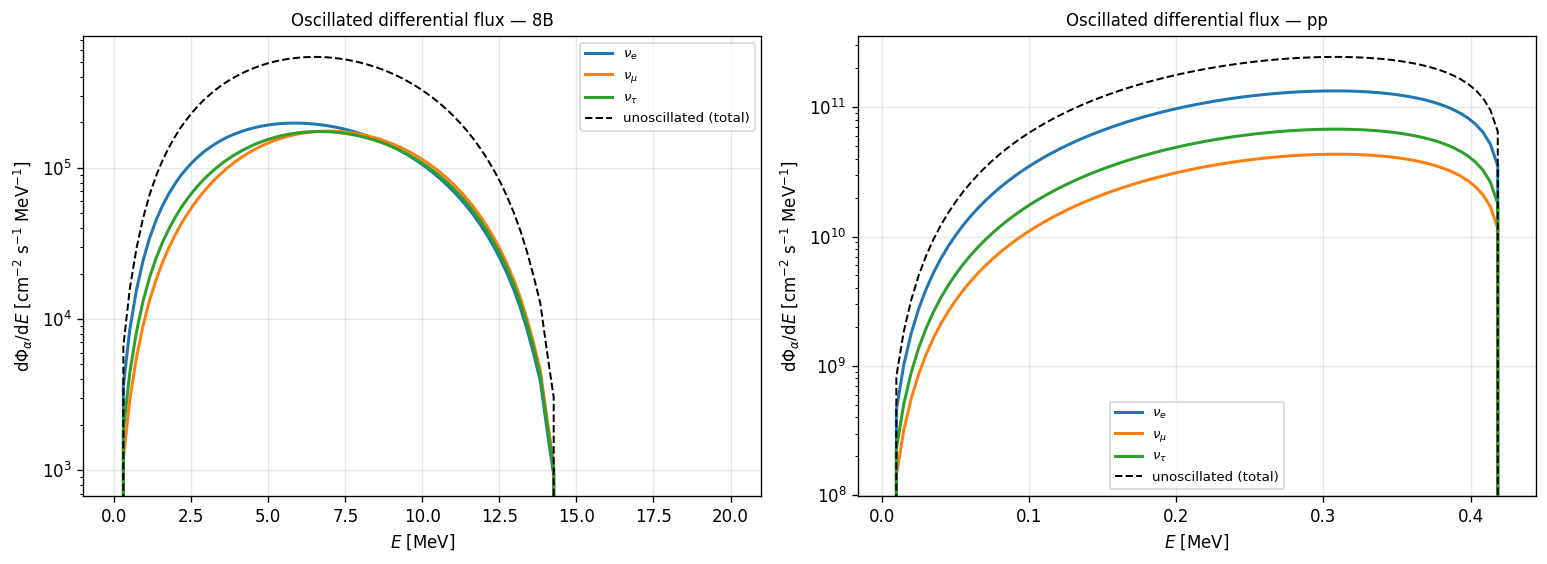

/mnt/v/output/validation/nusquids/vn5_fig31_differential_flux.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, source in zip(axes, ["8B", "pp"]):
    E_np = to_numpy(spectra[source]["E"])
    dphi0 = to_numpy(differential_flux(source, spectra[source]["E"]))
    P = to_numpy(solar_probability_state(oscillation, spectra[source]["E"], solar_profile, source))  # (nE, 3)
    for fi, (flabel, fcol) in enumerate(zip(FLAVOUR_LABELS, FLAVOUR_COLORS)):
        ax.plot(E_np, dphi0 * P[:, fi], color=fcol, lw=1.8, label=flabel)
    ax.plot(E_np, dphi0, color="k", ls="--", lw=1.2, label="unoscillated (total)")
    ax.set_xlabel(r"$E$ [MeV]")
    ax.set_ylabel(r"${\rm d}\Phi_\alpha/{\rm d}E$ [cm$^{-2}$ s$^{-1}$ MeV$^{-1}$]")
    ax.set_title(rf"Oscillated differential flux — {source}", fontsize=10)
    ax.set_yscale("log")
    ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("vn5_fig31_differential_flux.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)

## 4. Annual Earth-Regenerated Flux at Real Sites

Reuses `earth_probability_exposure` (validated in `Earth3`) with the real detector
latitudes from §2.3, now applied to the energy-differential flux built in
§3 rather than to a bare fixed-energy grid — this is the annually-averaged,
Earth-regeneration-corrected flux that actually reaches each detector over
a year of real Sun–Earth–detector geometry.

**Expected results:** SNO (highest latitude, 46.5°N) should show the
largest annually-averaged Earth-regeneration correction relative to the
vacuum (no-Earth) $^8$B flux; Borexino/GALLEX (42.5°N) an intermediate one.

In [6]:
earth_even = EarthProfile(
    params=EarthParameters(
        profile_perturbative_name="even_power",
        profile_perturbative_kwargs={"density_file": str(config.earth_density_file),
                                      "tabulated_density": False},
    ),
    context=ctx,
)
print("Earth profile ready:", earth_even)

Earth profile ready: EarthProfile | model=even_power | n_shells=5 | r=[0.1920, 1.0000] R_E (6371 km scale) | depth=0 m | method=analytical | cpu / torch.float64


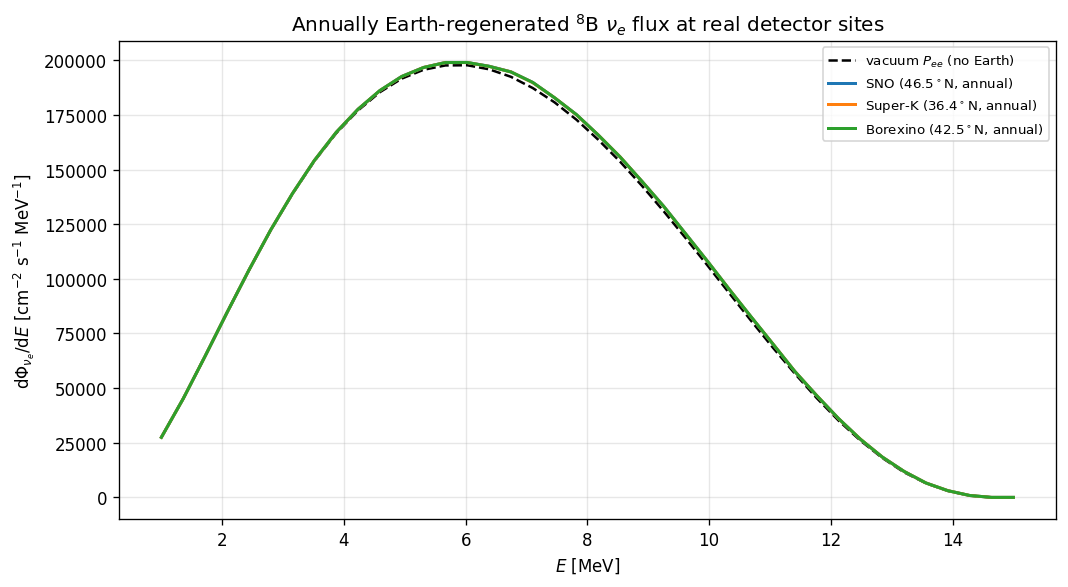

/mnt/v/output/validation/nusquids/vn5_fig41_annual_flux.png
SNO        (lat=46.47 N): mean annual Earth-regeneration boost on P_ee = 1.0142
Super-K    (lat=36.43 N): mean annual Earth-regeneration boost on P_ee = 1.0140
Borexino   (lat=42.45 N): mean annual Earth-regeneration boost on P_ee = 1.0141


In [7]:
E_8B = torch.linspace(1.0, 15.0, 40, dtype=ctx.dtype, device=ctx.device)
W_8B = solar_probability_mass(oscillation, E_8B, solar_profile, "8B")   # (nE, 3)
dphi0_8B = to_numpy(differential_flux("8B", E_8B))                     # (nE,)

P_annual_det = {}
for d in DETECTORS_ES:
    lat_rad = math.radians(d["lat_deg"])
    P_annual = earth_probability_exposure(
        W_8B, earth_even, oscillation, E_8B, EARTH_DEPTH_M,
        method="analytical", massbasis=True,
        exposure=ExposureParameters(detector_latitude_rad=lat_rad, exposure_ns=80),
        normalized_exposure=True, context=ctx,
    )  # (nE, 3)
    P_annual_det[d["name"]] = to_numpy(P_annual)

fig, ax = plt.subplots(figsize=(9, 5))
E_np = to_numpy(E_8B)
ax.plot(E_np, dphi0_8B * to_numpy(solar_probability_state(oscillation, E_8B, solar_profile, "8B"))[:, 0],
        "k--", lw=1.5, label=r"vacuum $P_{ee}$ (no Earth)")
for d in DETECTORS_ES:
    ax.plot(E_np, dphi0_8B * P_annual_det[d["name"]][:, 0], lw=1.8,
            label=rf"{d['name']} ({d['lat_deg']:.1f}$^\circ$N, annual)")
ax.set_xlabel(r"$E$ [MeV]")
ax.set_ylabel(r"${\rm d}\Phi_{\nu_e}/{\rm d}E$ [cm$^{-2}$ s$^{-1}$ MeV$^{-1}$]")
ax.set_title(r"Annually Earth-regenerated $^8$B $\nu_e$ flux at real detector sites")
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("vn5_fig41_annual_flux.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)

for d in DETECTORS_ES:
    boost = (P_annual_det[d["name"]][:, 0] / to_numpy(solar_probability_state(oscillation, E_8B, solar_profile, "8B"))[:, 0]).mean()
    print(f"{d['name']:10s} (lat={d['lat_deg']:5.2f} N): mean annual Earth-regeneration boost on P_ee = {boost:.4f}")

## 5. nuSQuIDS Cross-Check: Sun-to-Earth Regeneration

`external.nusquids.core` provides `probability_earth_massbasis` /
`transition_matrix_earth_mass_to_flavour`, which chain a solar mass-basis
state into nuSQuIDS's `Earth` body: each mass eigenstate $i$ is propagated
**separately** (a pure `Set_initial_state` in the **mass** basis), and the
incoherent solar mixture is recombined afterwards,

$$
P^{\rm nsq}_{e\alpha}(E,\eta) = \sum_i w_i(E)\,P^{\rm nsq}(\nu_i\to\nu_\alpha; E,\eta),
$$

using the same mass weights $w_i(E)$ from `solar_probability_mass` used
throughout this notebook. This is compared against `tpeanuts`'s own
`earth_probability_state_analytical(w_i, ..., massbasis=True)` at a few (E, $\eta$) points.

**A binding quirk worth documenting:** the installed nuSQuIDS 1.13.3
bindings' plain `Earth` body exposes **no** `MakeTrack`/`MakeTrackWithCosine`
convenience constructor — only the richer `EarthAtm` body (designed for
atmospheric neutrinos) does. `probability_earth_massbasis` works around this
by computing the physical chord baseline directly,
$L=\max(0,\,-2R_\oplus\cos\theta_z)$, and building an `Earth.Track(L)`
from it — the plain `Earth` body's real PREM density profile, without an
irrelevant atmosphere-production-height leg. This was confirmed by directly
introspecting the installed bindings (`dir(nsq.Earth)` exposes only `Track`,
`composition`, `density`, `ye` — no `MakeTrack*`) and by running the full
chain end-to-end against the real bindings.

**Geometry simplification for this comparison only:** `probability_earth_massbasis`
assumes a detector at the Earth's surface (depth 0), so the `tpeanuts` call
in this section also uses depth 0 here — unlike `EARTH_DEPTH_M = 2000` m
used elsewhere in this notebook (§4, §7) for the realistic detector depth.
The difference between 0 and 2000 m is $<0.05\%$ of $R_\oplus$ and
irrelevant to this cross-check (see §2.3).

**Expected results:** agreement at the percent level in the adiabatic $^8$B
regime, similar in spirit to the solar-surface comparison in
`nusquids2_solar.ipynb`, with any residual difference again attributable to
the Earth density-model difference (tpeanuts even-power/PREM vs nuSQuIDS's
internal `Earth`/PREM body) rather than to the propagation method itself.

In [8]:
def nusquids_mass_to_earth_flavour(w_mass, E_MeV, eta_rad, config=None):
    """Propagate an incoherent solar mass mixture through nuSQuIDS's Earth body.

    Thin wrapper around the shared `probability_earth_massbasis` helper
    (`external.nusquids.core`), which already builds a physically correct
    `Earth.Track` from a baseline chord length (no atmosphere leg) -- see
    the binding-quirk note in the markdown above. Converts tpeanuts's nadir
    angle to nuSQuIDS's cos(zenith) convention (complementary angles:
    cos_zenith = -cos(eta)). Returns NaNs if the installed bindings cannot
    do this at all (e.g. missing Basis.mass).
    """
    cos_zenith = -math.cos(float(eta_rad))
    try:
        return probability_earth_massbasis(
            E_GeV=float(E_MeV) * 1.0e-3,
            cos_zenith=cos_zenith,
            mass_weights=w_mass,
            antinu=False,
            config=config,
        )
    except Exception as exc:  # pragma: no cover - environment dependent
        print(f"  [skipped] nuSQuIDS mass-basis Earth propagation unavailable: {exc}")
        return np.full(3, float("nan"))


_NSQ_CFG = NuSQuIDSConfig(
    theta12=float(oscillation.pmns.params.theta12),
    theta13=float(oscillation.pmns.params.theta13),
    theta23=float(oscillation.pmns.params.theta23),
    delta_cp=float(oscillation.pmns.params.delta),
    DeltamSq21=float(oscillation.mass_spectrum.DeltamSq21),
    DeltamSq3l=float(oscillation.mass_spectrum.DeltamSq3l),
)

E_CHECK = [5.0, 10.0, 14.0]     # MeV, within the 8B window
ETA_CHECK = math.pi / 6         # fixed nadir angle, shallow mantle crossing
NSQ_CHECK_DEPTH_M = 0.0         # surface detector, matches probability_earth_massbasis

rows = []
for E_val in E_CHECK:
    E_t = torch.tensor(E_val, dtype=ctx.dtype, device=ctx.device)
    w_i = to_numpy(solar_probability_mass(oscillation, E_t, solar_profile, "8B"))  # (3,)

    eta_t = torch.tensor(ETA_CHECK, dtype=ctx.dtype, device=ctx.device)
    w_t = torch.as_tensor(w_i, dtype=ctx.dtype, device=ctx.device)
    P_tp = to_numpy(earth_probability_state_analytical(
        w_t, earth_even, oscillation, E_t, eta_t, NSQ_CHECK_DEPTH_M, massbasis=True,
    ))

    P_nsq = (
        nusquids_mass_to_earth_flavour(w_i, E_val, ETA_CHECK, config=_NSQ_CFG)
        if NSQ_AVAILABLE else np.full(3, float("nan"))
    )

    rows.append({
        "eta_rad": ETA_CHECK, "E_MeV": E_val,
        "P_nue_tp": P_tp[0], "P_numu_tp": P_tp[1], "P_nutau_tp": P_tp[2],
        "P_nue_nsq": P_nsq[0], "P_numu_nsq": P_nsq[1], "P_nutau_nsq": P_nsq[2],
    })
    print(f"E={E_val:5.1f} MeV: P_ee tpeanuts={P_tp[0]:.4f}  nuSQuIDS={P_nsq[0]:.4f}  "
          f"|diff|={abs(P_tp[0] - P_nsq[0]):.4e}")

nsq_earth_grid = pd.DataFrame(rows)
_KEY_COLS_N5 = ["eta_rad", "E_MeV"]
_tp_df_n5 = nsq_earth_grid[_KEY_COLS_N5 + ["P_nue_tp", "P_numu_tp", "P_nutau_tp"]].rename(
    columns={"P_nue_tp": "P_nue", "P_numu_tp": "P_numu", "P_nutau_tp": "P_nutau"}
)
_nsq_df_n5 = nsq_earth_grid[_KEY_COLS_N5 + ["P_nue_nsq", "P_numu_nsq", "P_nutau_nsq"]].rename(
    columns={"P_nue_nsq": "P_nue", "P_numu_nsq": "P_numu", "P_nutau_nsq": "P_nutau"}
)
nsq_earth_comparison = compare_probability_grids(_tp_df_n5, _nsq_df_n5, _KEY_COLS_N5)
nsq_earth_summary = nusquids_precision_summary(nsq_earth_comparison)
print()
print(nsq_earth_summary.to_string())

E=  5.0 MeV: P_ee tpeanuts=0.3885  nuSQuIDS=0.3887  |diff|=1.9439e-04
E= 10.0 MeV: P_ee tpeanuts=0.3358  nuSQuIDS=0.3406  |diff|=4.7798e-03
E= 14.0 MeV: P_ee tpeanuts=0.2967  nuSQuIDS=0.3023  |diff|=5.5859e-03

                        value
metric                       
rows_compared             3.0
max_abs_err          0.005586
median_abs_err        0.00478
max_rel_err          0.018478
median_rel_err       0.014033
status                  CHECK
max_abs_err_P_nue    0.005586
max_abs_err_P_numu   0.002631
max_abs_err_P_nutau  0.003281


## 6. Detection Cross Sections

Implements the total tree-level $\nu$–$e^-$ elastic-scattering cross section
of §0.3 as a plain function of energy and flavour, reusing `tpeanuts`'s own
`G_F_MEV_M2` and `HBARC_MeV_m` physical constants for the unit conversion
(no new physical constant is introduced).

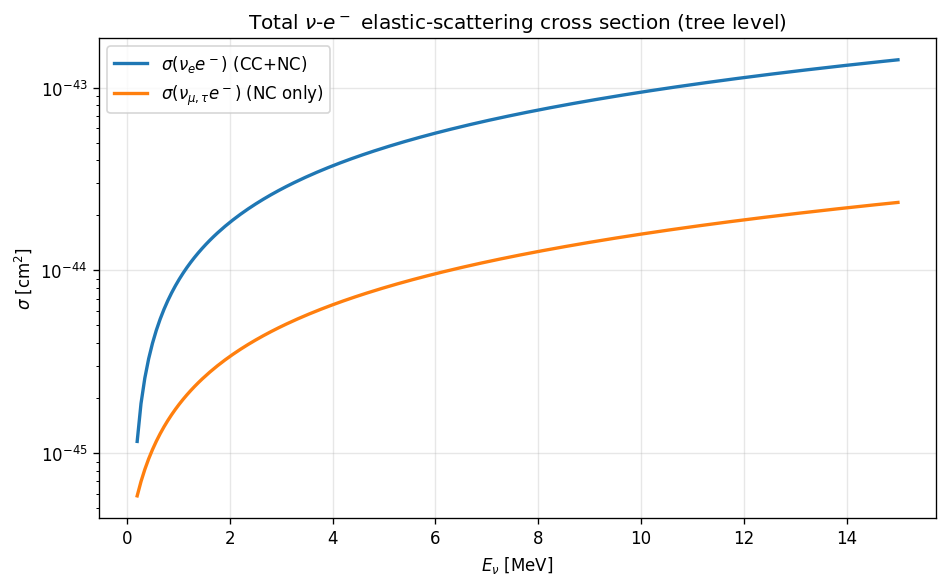

/mnt/v/output/validation/nusquids/vn5_fig6_sigma_es.png
sigma(nu_e,  E=10 MeV) = 9.4461e-44 cm^2
sigma(nu_mu, E=10 MeV) = 1.5795e-44 cm^2  (ratio nu_e/nu_mu = 5.98)


In [9]:
def sigma_es(E_MeV, is_nue, *, m_e=ELECTRON_MASS_MEV, sin2w=SIN2_THETAW):
    """Total nu-e elastic-scattering cross section in cm^2 (tree level, E >> m_e)."""
    E_MeV = np.asarray(E_MeV, dtype=float)
    g1 = (0.5 + sin2w) if is_nue else (-0.5 + sin2w)
    g2 = sin2w
    bracket = g1**2 + g2**2 / 3.0 - g1 * g2 * m_e / (2.0 * np.maximum(E_MeV, 1e-6))
    sigma_m2 = (2.0 / math.pi) * constant.G_F_MEV_M2**2 * m_e * E_MeV * bracket * constant.HBARC_MeV_m**2
    return np.clip(sigma_m2, 0.0, None) * 1.0e4   # m^2 -> cm^2


E_plot = np.linspace(0.2, 15.0, 200)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(E_plot, sigma_es(E_plot, is_nue=True), label=r"$\sigma(\nu_e e^-)$ (CC+NC)", lw=2.0)
ax.plot(E_plot, sigma_es(E_plot, is_nue=False), label=r"$\sigma(\nu_{\mu,\tau} e^-)$ (NC only)", lw=2.0)
ax.set_xlabel(r"$E_\nu$ [MeV]")
ax.set_ylabel(r"$\sigma$ [cm$^2$]")
ax.set_yscale("log")
ax.set_title(r"Total $\nu$-$e^-$ elastic-scattering cross section (tree level)")
ax.legend()
fig.tight_layout()
save_and_show("vn5_fig6_sigma_es.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)

print(f"sigma(nu_e,  E=10 MeV) = {sigma_es(10.0, True):.4e} cm^2")
print(f"sigma(nu_mu, E=10 MeV) = {sigma_es(10.0, False):.4e} cm^2  "
      f"(ratio nu_e/nu_mu = {sigma_es(10.0, True) / sigma_es(10.0, False):.2f})")

## 7. Annual Event-Rate Predictions

Combines every previous section into a single number per detector: annual
counts, with and without oscillations. ES detectors (SNO, Super-K, Borexino)
use the annually Earth-regenerated flavour-resolved flux from §4 and the
cross section from §6, integrated above each detector's threshold. The
radiochemical detectors (Homestake, GALLEX/SAGE) use the SNU convention of
§0.4: the oscillation suppression factor is computed here from the real
threshold-weighted spectrum, applied to the literature no-oscillation SNU
reference.

**Expected results:** SNO/Super-K/Borexino oscillated rates should sit at
roughly $\langle P_{ee}\rangle$ times the unoscillated rate for their source;
Homestake/GALLEX predicted SNU should land closer to the historically
measured value than the no-oscillation prediction, reproducing (at
order-of-magnitude level) the classic "solar neutrino problem" resolution.

In [10]:
def n_target_es(mass_kg, molar_mass_g, electrons_per_molecule):
    moles = (mass_kg * 1000.0) / molar_mass_g
    return moles * constant.N_A * electrons_per_molecule


def annual_counts_es(detector, oscillation, *, use_annual_earth=True):
    source = detector["source"]
    E_native = spectra[source]["E"]
    mask = E_native >= detector["e_thr_MeV"]
    E_sel = E_native[mask]
    if E_sel.numel() < 2:
        return 0.0, 0.0

    dphi0 = to_numpy(differential_flux(source, E_sel))  # (n,)

    if use_annual_earth:
        W = solar_probability_mass(oscillation, E_sel, solar_profile, source)
        lat_rad = math.radians(detector["lat_deg"])
        P = to_numpy(earth_probability_exposure(
            W, earth_even, oscillation, E_sel, EARTH_DEPTH_M,
            method="analytical", massbasis=True,
            exposure=ExposureParameters(detector_latitude_rad=lat_rad, exposure_ns=60),
            normalized_exposure=True, context=ctx,
        ))
    else:
        P = to_numpy(solar_probability_state(oscillation, E_sel, solar_profile, source))

    E_np = to_numpy(E_sel)
    sig_e  = sigma_es(E_np, is_nue=True)
    sig_mt = sigma_es(E_np, is_nue=False)

    n_target = n_target_es(detector["mass_kg"], detector["molar_mass_g"], detector["electrons_per_molecule"])

    rate_osc = n_target * numpy_trapezoid(
        dphi0 * (sig_e * P[:, 0] + sig_mt * (P[:, 1] + P[:, 2])), E_np,
    )
    rate_no_osc = n_target * numpy_trapezoid(dphi0 * sig_e, E_np)  # P_ee = 1, no matter effect
    return rate_osc * SECONDS_PER_YEAR, rate_no_osc * SECONDS_PER_YEAR


es_rows = []
for d in DETECTORS_ES:
    counts_osc, counts_no_osc = annual_counts_es(d, oscillation)
    es_rows.append({
        "Detector": d["name"], "Source": d["source"],
        "Counts/yr (no osc)": counts_no_osc, "Counts/yr (oscillated)": counts_osc,
        "Suppression": counts_osc / counts_no_osc if counts_no_osc > 0 else float("nan"),
    })
es_rate_table = pd.DataFrame(es_rows)
print(es_rate_table.to_string(index=False))

Detector Source  Counts/yr (no osc)  Counts/yr (oscillated)  Suppression
     SNO     8B         2370.200774             1088.396873     0.459200
 Super-K     8B        55973.391005            25514.931697     0.455840
Borexino    7Be        34517.209701            21754.382610     0.630247


In [11]:
def snu_suppression_factor(detector, oscillation):
    """Threshold-weighted <P_ee> ratio used to rescale the no-oscillation SNU rate.

    Combines the pp, 7Be, and 8B sources above the detector's CC threshold,
    weighted by their (unoscillated) differential flux -- this is the
    physically meaningful weighting for a CC-only radiochemical response.
    """
    num, den = 0.0, 0.0
    for source in ("pp", "7Be", "8B"):
        E_native = spectra[source]["E"]
        mask = E_native >= detector["e_thr_MeV"]
        E_sel = E_native[mask]
        if E_sel.numel() < 2:
            continue
        dphi0 = to_numpy(differential_flux(source, E_sel))
        P_ee = to_numpy(solar_probability_state(oscillation, E_sel, solar_profile, source))[:, 0]
        E_np = to_numpy(E_sel)
        num += numpy_trapezoid(dphi0 * P_ee, E_np)
        den += numpy_trapezoid(dphi0, E_np)
    return (num / den) if den > 0 else float("nan")


cc_rows = []
for d in DETECTORS_CC:
    supp = snu_suppression_factor(d, oscillation)
    snu_pred = d["snu_no_osc"] * supp
    cc_rows.append({
        "Detector": d["name"],
        "SNU (no osc, literature)": d["snu_no_osc"],
        "Suppression <P_ee> (this notebook)": supp,
        "SNU (predicted, oscillated)": snu_pred,
        "SNU (measured, literature)": d["snu_measured"],
    })
cc_rate_table = pd.DataFrame(cc_rows)
print(cc_rate_table.to_string(index=False))

   Detector  SNU (no osc, literature)  Suppression <P_ee> (this notebook)  SNU (predicted, oscillated)  SNU (measured, literature)
  Homestake                       8.0                            0.528492                     4.227935                        2.56
GALLEX/SAGE                     128.0                            0.544272                    69.666878                       70.00


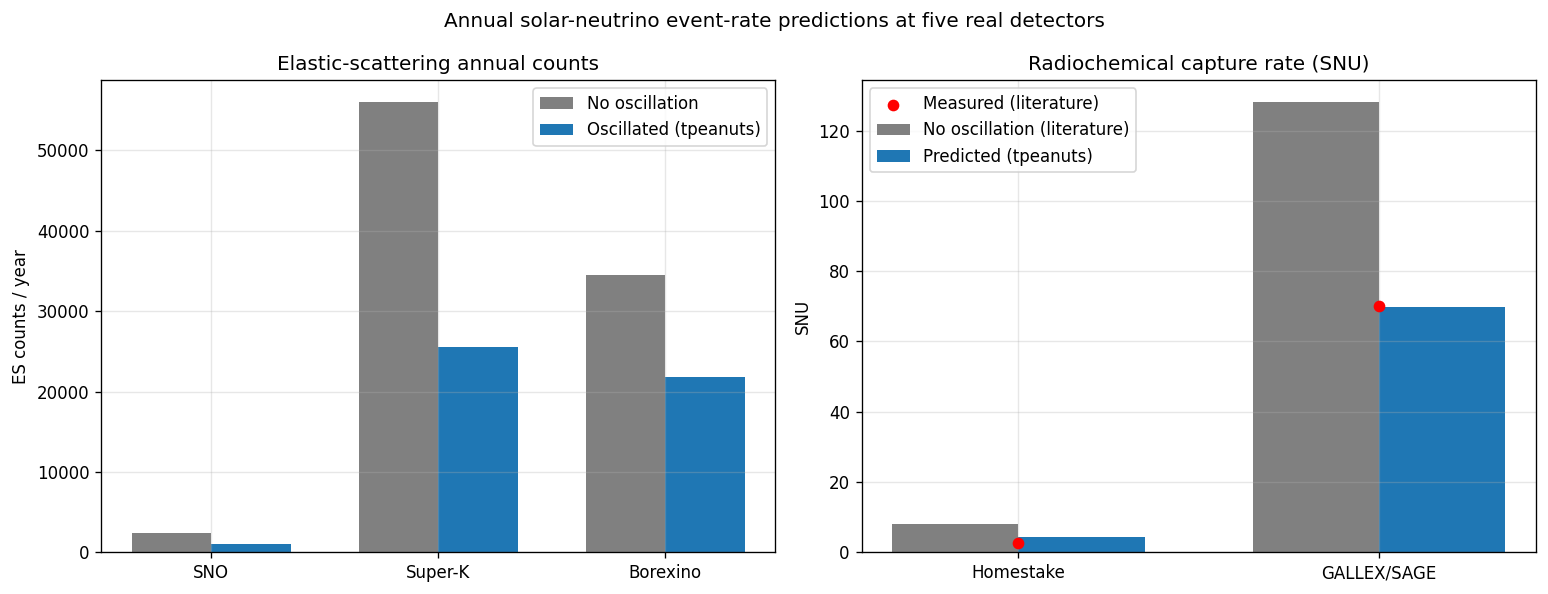

/mnt/v/output/validation/nusquids/vn5_fig71_annual_counts.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
x = np.arange(len(es_rate_table))
width = 0.35
ax.bar(x - width / 2, es_rate_table["Counts/yr (no osc)"], width, label="No oscillation", color="gray")
ax.bar(x + width / 2, es_rate_table["Counts/yr (oscillated)"], width, label="Oscillated (tpeanuts)", color="C0")
ax.set_xticks(x)
ax.set_xticklabels(es_rate_table["Detector"])
ax.set_ylabel("ES counts / year")
ax.set_title("Elastic-scattering annual counts")
ax.legend()

ax = axes[1]
x = np.arange(len(cc_rate_table))
ax.bar(x - width / 2, cc_rate_table["SNU (no osc, literature)"], width, label="No oscillation (literature)", color="gray")
ax.bar(x + width / 2, cc_rate_table["SNU (predicted, oscillated)"], width, label="Predicted (tpeanuts)", color="C0")
ax.scatter(x, cc_rate_table["SNU (measured, literature)"], color="red", zorder=5, label="Measured (literature)")
ax.set_xticks(x)
ax.set_xticklabels(cc_rate_table["Detector"])
ax.set_ylabel("SNU")
ax.set_title("Radiochemical capture rate (SNU)")
ax.legend()

fig.suptitle("Annual solar-neutrino event-rate predictions at five real detectors", fontsize=12)
fig.tight_layout()
save_and_show("vn5_fig71_annual_counts.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)

## 8. Export Tables

In [13]:
es_rate_table.to_csv(OUTPUT_DIR / "vn5_es_annual_counts.csv", index=False)
cc_rate_table.to_csv(OUTPUT_DIR / "vn5_cc_annual_snu.csv", index=False)
print("Saved:", OUTPUT_DIR / "vn5_es_annual_counts.csv")
print("Saved:", OUTPUT_DIR / "vn5_cc_annual_snu.csv")

if not nsq_earth_comparison.empty:
    nsq_earth_comparison.to_csv(OUTPUT_DIR / "vn5_earth_comparison.csv", index=False)
    nsq_earth_summary.to_csv(OUTPUT_DIR / "vn5_earth_summary.csv")
    print("Saved:", OUTPUT_DIR / "vn5_earth_comparison.csv")
    print("Saved:", OUTPUT_DIR / "vn5_earth_summary.csv")
    print("(picked up by nusquids0_summary.ipynb's *_comparison.csv aggregation)")

Saved: /mnt/v/output/validation/nusquids/vn5_es_annual_counts.csv
Saved: /mnt/v/output/validation/nusquids/vn5_cc_annual_snu.csv
Saved: /mnt/v/output/validation/nusquids/vn5_earth_comparison.csv
Saved: /mnt/v/output/validation/nusquids/vn5_earth_summary.csv
(picked up by nusquids0_summary.ipynb's *_comparison.csv aggregation)


## 9. Summary

### API Coverage

| Function | Section | Role |
|----------|---------|------|
| `load_spectrum_csv` | §2.2 | per-source B16 spectral shape (first use in any notebook) |
| `solar_probability_state` / `solar_probability_mass` | §3, §5, §7 | oscillated probability / mass weights |
| `earth_probability_state_analytical` / `earth_probability_exposure` | §4, §5, §7 | Earth regeneration, annual exposure average |
| `build_nadir_exposure` / `ExposureParameters` | §4, §7 | annual nadir-angle exposure at a real latitude |
| `sigma_es` (new, this notebook) | §6–§7 | tree-level $\nu$-$e^-$ ES cross section |
| nuSQuIDS mass-basis `Earth` chaining (new, this notebook) | §5 | independent cross-check of Sun→Earth regeneration |

### Validation Notes

- §5 is the first notebook in this repository to chain nuSQuIDS's solar
  output into its `Earth` body; if the installed bindings lack
  `nsq.Basis.mass` or an `Earth`/`EarthAtm` body, the comparison degrades to
  NaN with a printed message rather than failing the notebook.
- The ES cross section (§6) is exact tree-level electroweak physics; the
  Homestake/GALLEX absolute SNU scale (§7) is anchored to one literature
  number per experiment and should not be read as a precision reproduction
  of either the standard solar model or the experimental analyses — the
  oscillation *suppression ratio* is what this notebook actually computes
  and validates.

In [14]:
print("=" * 60)
print("VALIDATION SUMMARY -- NuSQuIDS 5: Solar Neutrino Earth Detection")
print("=" * 60)
print(es_rate_table.to_string(index=False))
print()
print(cc_rate_table.to_string(index=False))
print()
if NSQ_AVAILABLE and not nsq_earth_comparison.empty and nsq_earth_comparison["P_nue_nsq"].notna().any():
    print(f"Max |P_ee tpeanuts - nuSQuIDS| (Sun->Earth, 8B): "
          f"{nsq_earth_comparison['abs_err_P_nue'].max():.4e}")
else:
    print("nuSQuIDS Sun->Earth cross-check unavailable in this environment (see §5).")

VALIDATION SUMMARY -- NuSQuIDS 5: Solar Neutrino Earth Detection
Detector Source  Counts/yr (no osc)  Counts/yr (oscillated)  Suppression
     SNO     8B         2370.200774             1088.396873     0.459200
 Super-K     8B        55973.391005            25514.931697     0.455840
Borexino    7Be        34517.209701            21754.382610     0.630247

   Detector  SNU (no osc, literature)  Suppression <P_ee> (this notebook)  SNU (predicted, oscillated)  SNU (measured, literature)
  Homestake                       8.0                            0.528492                     4.227935                        2.56
GALLEX/SAGE                     128.0                            0.544272                    69.666878                       70.00

Max |P_ee tpeanuts - nuSQuIDS| (Sun->Earth, 8B): 5.5859e-03
